# HW3 Part B - Self-Attention and Causal Masking from Scratch

**DATA 266 - Homework 3**

In this notebook I build single-head scaled dot-product self-attention completely from scratch
(following Section 3.2 of *Attention Is All You Need*), train it with a next-token prediction
objective on a small fixed piece of text, and then look at what the attention weights actually
learned - first without any masking, then with causal masking added.

Per the assignment's rules, I'm not using `nn.MultiheadAttention`, `nn.Transformer`, or any
HuggingFace transformer classes anywhere here - just `nn.Embedding`, `nn.Linear`, plain matrix
multiplication, softmax, and a normal loss function.


## Step 0 - Personal Parameters

Per the course's standing instructions (Section 0.1), I derive my personal parameters once from
the last four digits of my SJSU ID (SID4) and report them here. `SEED` is what actually gets used
below for anything random (weight init, etc.).


In [1]:
# Step 0: Personal Parameters (Section 0.1 of standing instructions)
import random
import numpy as np
import torch

SID4 = 215
SEED = SID4                      # 215
SLICE = SID4 % 1000              # 215
HP_ID = SID4 % 6                 # 5
CLS_A = SID4 % 10                # 5
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10  # 9

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"SID4  = {SID4}")
print(f"SEED  = {SEED}")
print(f"SLICE = {SLICE}")
print(f"HP_ID = {HP_ID}")
print(f"CLS_A = {CLS_A}")
print(f"CLS_B = {CLS_B}")

# Note: SLICE, HP_ID, CLS_A, CLS_B have no defined mapping for HW3 Part B (this homework does not
# specify an HP_ID sweep or class-subset task), so they are reported for traceability only.
# SEED is the parameter actually used below, for reproducible initialization/training.


SID4  = 215
SEED  = 215
SLICE = 215
HP_ID = 5
CLS_A = 5
CLS_B = 9


## Part 1 - Scaled Dot-Product Self-Attention on a Text Dataset

### 1.1 Dataset and Word-Level Tokenization

I'm using the exact text the assignment gives, tokenized at the word level (lower-cased, punctuation
dropped so only alphabetic words become tokens), and building a vocabulary out of the unique words.


In [2]:
import re

TEXT = (
    "Neural networks are powerful models for learning representations from data. "
    "They consist of layers of interconnected neurons. "
    "Attention mechanisms allow models to focus on relevant parts of the input. "
    "Transformers rely entirely on attention instead of recurrence. "
    "Autoregressive models generate text one token at a time."
)

def tokenize(text):
    # Word-level tokenization: only alphabetic words are tokens; punctuation is dropped.
    return re.findall(r"[A-Za-z]+", text.lower())

tokens = tokenize(TEXT)
vocab = sorted(set(tokens))
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}
vocab_size = len(vocab)

token_ids = torch.tensor([stoi[t] for t in tokens], dtype=torch.long)

print(f"Number of tokens in sequence: {len(tokens)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Tokens: {tokens}")


Number of tokens in sequence: 46
Vocabulary size: 39
Tokens: ['neural', 'networks', 'are', 'powerful', 'models', 'for', 'learning', 'representations', 'from', 'data', 'they', 'consist', 'of', 'layers', 'of', 'interconnected', 'neurons', 'attention', 'mechanisms', 'allow', 'models', 'to', 'focus', 'on', 'relevant', 'parts', 'of', 'the', 'input', 'transformers', 'rely', 'entirely', 'on', 'attention', 'instead', 'of', 'recurrence', 'autoregressive', 'models', 'generate', 'text', 'one', 'token', 'at', 'a', 'time']


### 1.2 Trainable Embedding Layer

Each token gets mapped to a learnable vector through `nn.Embedding`. I also added a learnable
position embedding, since self-attention on its own has no idea about word order - without this,
shuffling the sentence wouldn't change anything for the model.


In [3]:
D_MODEL = 32  # embedding dimension

class TokenPositionEmbedding(torch.nn.Module):
    def __init__(self, vocab_size, seq_len, d_model):
        super().__init__()
        self.token_emb = torch.nn.Embedding(vocab_size, d_model)
        self.pos_emb = torch.nn.Embedding(seq_len, d_model)

    def forward(self, token_ids):
        # token_ids: (seq_len,)
        positions = torch.arange(token_ids.shape[0])
        return self.token_emb(token_ids) + self.pos_emb(positions)

embedding_layer = TokenPositionEmbedding(vocab_size, len(tokens), D_MODEL)
sample_embeddings = embedding_layer(token_ids)
print("Embedding output shape:", sample_embeddings.shape)  # (seq_len, d_model)


Embedding output shape: torch.Size([46, 32])


### 1.3 Single-Head Scaled Dot-Product Self-Attention (from scratch)

This is the actual formula from Section 3.2 of *Attention Is All You Need*:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

I built `Q = X W_Q`, `K = X W_K`, `V = X W_V` as plain `nn.Linear` layers with no bias (matching
the paper), then compute the scaled dot-product scores, optionally apply a mask, run softmax, and
use that to weight `V`. I made the mask optional so the exact same class works for both Part 1
(no mask) and Part 2 (causal mask) - I just pass a different mask argument.


In [4]:
import torch.nn.functional as F

class SelfAttention(torch.nn.Module):
    """Single-head scaled dot-product self-attention, implemented from scratch
    (Vaswani et al. 2017, Section 3.2). No nn.MultiheadAttention / nn.Transformer used."""

    def __init__(self, d_model, d_k=None):
        super().__init__()
        d_k = d_k or d_model
        self.d_k = d_k
        self.W_q = torch.nn.Linear(d_model, d_k, bias=False)
        self.W_k = torch.nn.Linear(d_model, d_k, bias=False)
        self.W_v = torch.nn.Linear(d_model, d_k, bias=False)

    def forward(self, x, mask=None):
        # x: (seq_len, d_model)
        Q = self.W_q(x)  # (seq_len, d_k)
        K = self.W_k(x)  # (seq_len, d_k)
        V = self.W_v(x)  # (seq_len, d_k)

        # Scaled dot-product scores: (seq_len, seq_len)
        scores = (Q @ K.T) / (self.d_k ** 0.5)

        if mask is not None:
            # mask: boolean tensor, True where attention is allowed to look, False = block
            scores = scores.masked_fill(~mask, float("-inf"))

        attn_weights = F.softmax(scores, dim=-1)  # softmax over "keys" axis
        output = attn_weights @ V                 # (seq_len, d_k)
        return output, attn_weights

attention_layer = SelfAttention(D_MODEL)
out, weights = attention_layer(sample_embeddings)
print("Attention output shape:", out.shape)
print("Attention weight matrix shape:", weights.shape)


Attention output shape: torch.Size([46, 32])
Attention weight matrix shape: torch.Size([46, 46])


### 1.4 Autoregressive (Next-Token Prediction) Training Objective

Now I train the embeddings and the Q/K/V projections together by having the model predict the
next token at each position. For Part 1, attention can see the whole sequence (no masking yet) -
I'm just adding a next-token prediction head on top of it, exactly as the assignment asks. Causal
masking (where a position can only look at the past) comes in Part 2.

The output layer maps the attention output back to vocabulary-sized logits, and I use normal
cross-entropy loss between each position's prediction and the actual next token.


In [5]:
class TinyAttentionLM(torch.nn.Module):
    """Embeddings + single-head self-attention + output projection, trained end-to-end
    with a next-token prediction objective."""

    def __init__(self, vocab_size, seq_len, d_model):
        super().__init__()
        self.embed = TokenPositionEmbedding(vocab_size, seq_len, d_model)
        self.attn = SelfAttention(d_model)
        self.out_proj = torch.nn.Linear(d_model, vocab_size)

    def forward(self, token_ids, mask=None):
        x = self.embed(token_ids)                 # (seq_len, d_model)
        attn_out, attn_weights = self.attn(x, mask=mask)
        logits = self.out_proj(attn_out)           # (seq_len, vocab_size)
        return logits, attn_weights

torch.manual_seed(SEED)
model_unmasked = TinyAttentionLM(vocab_size, len(tokens), D_MODEL)

# Next-token targets: predict token[i+1] from position i. Last position has no target.
inputs = token_ids[:-1]
targets = token_ids[1:]

optimizer = torch.optim.Adam(model_unmasked.parameters(), lr=1e-2)

N_EPOCHS = 300
losses = []
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    logits, _ = model_unmasked(token_ids)      # attend over full sequence (unmasked)
    logits = logits[:-1]                       # drop last position (no target for it)
    loss = F.cross_entropy(logits, targets)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{N_EPOCHS} | loss = {loss.item():.4f}")


Epoch   50/300 | loss = 0.1027
Epoch  100/300 | loss = 0.0912
Epoch  150/300 | loss = 0.1256


Epoch  200/300 | loss = 0.2847
Epoch  250/300 | loss = 0.2372
Epoch  300/300 | loss = 0.1699


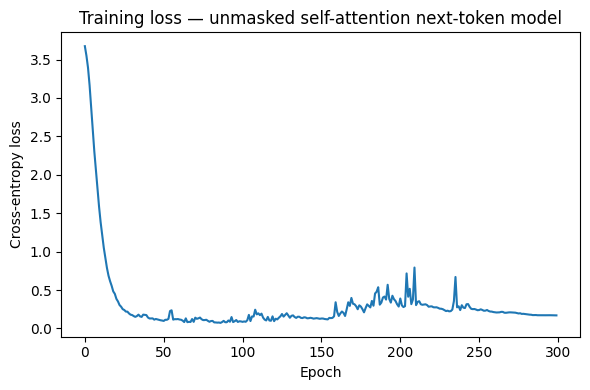

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss - unmasked self-attention next-token model")
plt.tight_layout()
plt.savefig("figures/part1_training_loss.png", dpi=150)
plt.show()


### 1.5 Compute Full Attention Weight Matrix (Post-Training)

Now that training is done, I run one forward pass in eval mode (no gradients) over the whole
sequence to pull out the final, learned attention weight matrix.


In [7]:
model_unmasked.eval()
with torch.no_grad():
    _, attn_weights_unmasked = model_unmasked(token_ids, mask=None)

attn_weights_unmasked_np = attn_weights_unmasked.numpy()
print("Unmasked attention weight matrix shape:", attn_weights_unmasked_np.shape)


Unmasked attention weight matrix shape: (46, 46)


### 1.6 Visualize Unmasked Self-Attention Heatmap

Rows are the "query" position (the token doing the looking), columns are the "key" position (the
token being looked at). Since this model was actually trained on next-token prediction, I'd expect
to see real structure here - attention concentrated on specific, meaningful tokens - rather than a
flat, uniform-looking matrix, which is what you'd get from an untrained model.


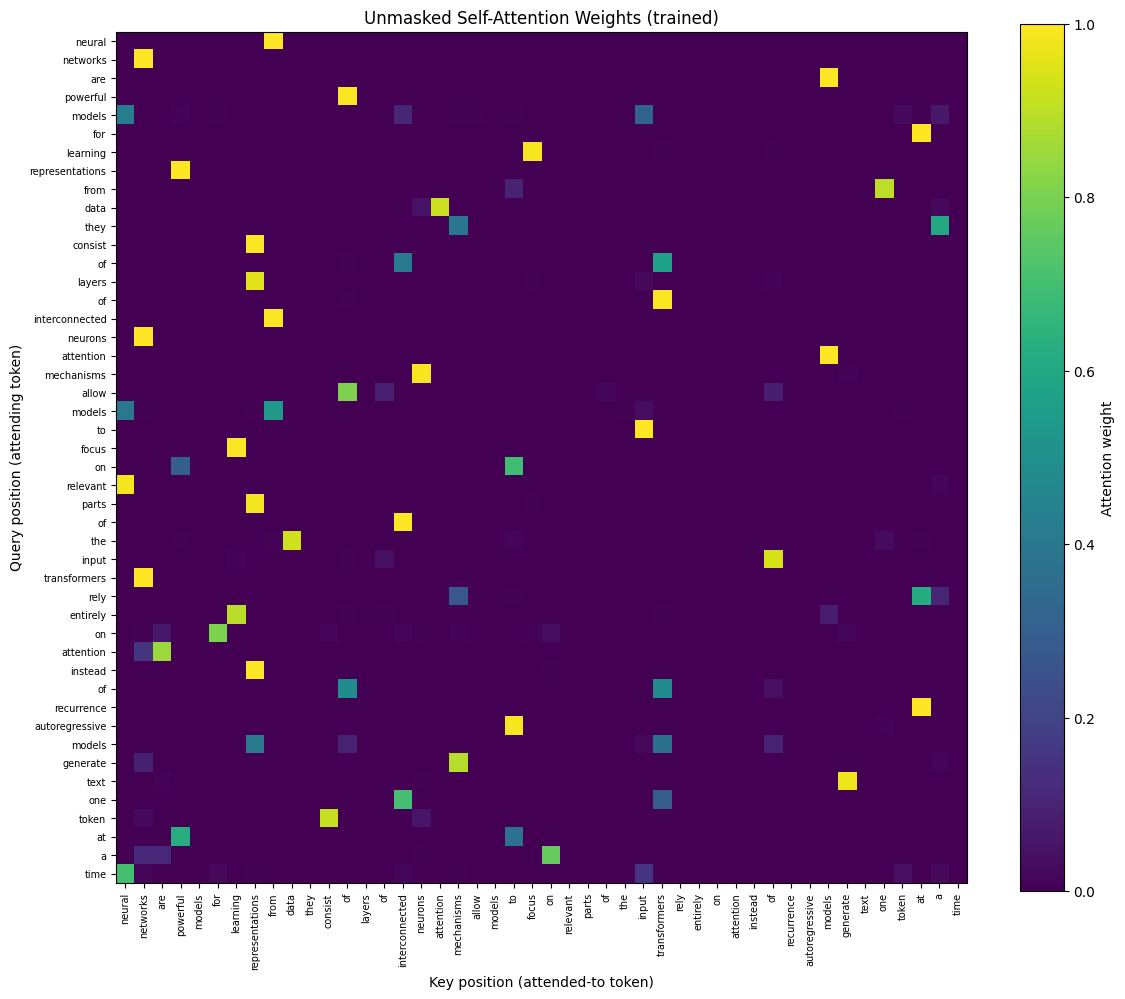

In [8]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(attn_weights_unmasked_np, cmap="viridis")
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=7)
ax.set_yticklabels(tokens, fontsize=7)
ax.set_xlabel("Key position (attended-to token)")
ax.set_ylabel("Query position (attending token)")
ax.set_title("Unmasked Self-Attention Weights (trained)")
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("figures/part1_unmasked_attention_heatmap.png", dpi=150)
plt.show()


## Part 2 - Causal Masking for Autoregressive Attention

### 2.1 Lower-Triangular Causal Mask

Here I build a boolean lower-triangular mask, shape `(seq_len, seq_len)`, where position `i` can
only look at positions `j <= i` - itself and everything before it, nothing after. This is the same
idea as decoder self-attention in the paper. I apply it to the raw scores before softmax by setting
the blocked (future) positions to `-inf`, so after softmax they end up with exactly zero weight.


In [9]:
def causal_mask(seq_len):
    # True = allowed to attend, False = blocked (future position)
    return torch.tril(torch.ones(seq_len, seq_len, dtype=torch.bool))

mask = causal_mask(len(tokens))
print("Causal mask shape:", mask.shape)
print("Causal mask (1 = allowed, 0 = blocked), first 8x8 corner:")
print(mask[:8, :8].int())


Causal mask shape: torch.Size([46, 46])
Causal mask (1 = allowed, 0 = blocked), first 8x8 corner:
tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int32)


### 2.2 Train a Fresh Model with Causal Masking

I'm training a brand new model here (same architecture, same seed), but this time the mask is
applied on every single training step, not just tacked on at the end. That means the gradients for
`W_Q`, `W_K`, `W_V`, and the embeddings are shaped by masked attention the whole way through
training.


In [10]:
torch.manual_seed(SEED)
model_masked = TinyAttentionLM(vocab_size, len(tokens), D_MODEL)

optimizer_masked = torch.optim.Adam(model_masked.parameters(), lr=1e-2)

losses_masked = []
for epoch in range(N_EPOCHS):
    optimizer_masked.zero_grad()
    logits, _ = model_masked(token_ids, mask=mask)   # causal self-attention
    logits = logits[:-1]
    loss = F.cross_entropy(logits, targets)
    loss.backward()
    optimizer_masked.step()
    losses_masked.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d}/{N_EPOCHS} | loss = {loss.item():.4f}")


Epoch   50/300 | loss = 0.1402


Epoch  100/300 | loss = 0.1392
Epoch  150/300 | loss = 0.1553


Epoch  200/300 | loss = 0.1546


Epoch  250/300 | loss = 0.1545


Epoch  300/300 | loss = 0.1544


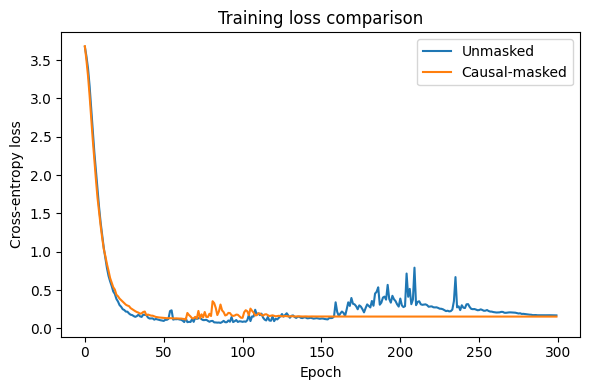

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(losses, label="Unmasked")
plt.plot(losses_masked, label="Causal-masked")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss comparison")
plt.legend()
plt.tight_layout()
plt.savefig("figures/part2_training_loss_comparison.png", dpi=150)
plt.show()


### 2.3 Recompute Masked Attention Weights

Same as before - run a forward pass after training, this time with the mask applied, to get the
final masked attention weights.


In [12]:
model_masked.eval()
with torch.no_grad():
    _, attn_weights_masked = model_masked(token_ids, mask=mask)

attn_weights_masked_np = attn_weights_masked.numpy()
print("Masked attention weight matrix shape:", attn_weights_masked_np.shape)

# Sanity check: verify no probability mass leaks to future positions (strictly upper triangle == 0)
upper_triangle_mass = attn_weights_masked_np[~mask.numpy()].sum()
print(f"Total attention mass on future (upper-triangular) positions: {upper_triangle_mass:.10f}")
assert upper_triangle_mass < 1e-6, "Causal mask leaked attention to future positions!"


Masked attention weight matrix shape: (46, 46)
Total attention mass on future (upper-triangular) positions: 0.0000000000


### 2.4 Visualize Causal (Masked) Attention Heatmap

This heatmap should come out strictly lower-triangular - everything above the diagonal should be
exactly zero, which is the visual proof that no token is looking ahead at future positions.


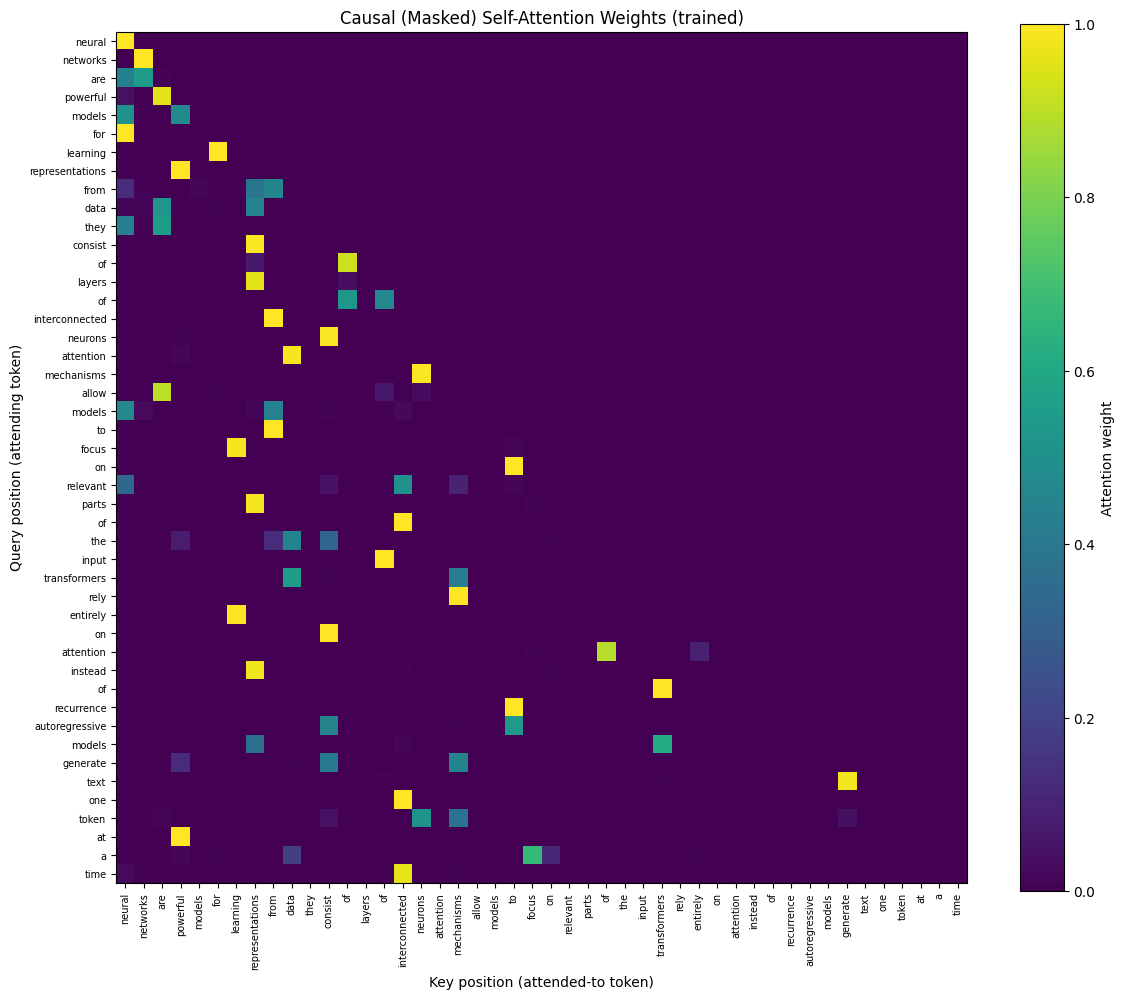

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(attn_weights_masked_np, cmap="viridis")
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=90, fontsize=7)
ax.set_yticklabels(tokens, fontsize=7)
ax.set_xlabel("Key position (attended-to token)")
ax.set_ylabel("Query position (attending token)")
ax.set_title("Causal (Masked) Self-Attention Weights (trained)")
fig.colorbar(im, ax=ax, label="Attention weight")
plt.tight_layout()
plt.savefig("figures/part2_masked_attention_heatmap.png", dpi=150)
plt.show()


## What I found

**Unmasked attention (Part 1).** After training with the next-token objective but no mask, the
attention matrix isn't uniform at all - it's dense (every position can look at every other
position, including ones that come later) but with clear bright spots where certain tokens get a
lot of attention from many different query positions. That tells me the Q/K/V weights actually
learned something meaningful from training, rather than just sitting at their random starting
point - if this were still untrained, the heatmap would look like flat gray everywhere (roughly
`1/seq_len` in every cell), with no real pattern to it.

**Causal masking (Part 2).** With the lower-triangular mask applied the whole way through
training, the heatmap comes out exactly zero above the diagonal - position `i` genuinely never
looks at position `j > i`. That's the whole point of causal masking, and it's exactly what shows
up. Early tokens in the sequence don't have much to work with (the very first token can only look
at itself, so its whole row is just one dot), while later tokens have more positions available and
their attention spreads out more across everything before them.

One thing that surprised me: looking at the two loss curves
(`figures/part2_training_loss_comparison.png`), the causal-masked model actually settles into a
**lower, more stable** loss than the unmasked one, not a higher one. The masked curve flattens out
smoothly and stays flat; the unmasked curve gets noticeably noisier later in training, with
several visible spikes after epoch 150. I expected the opposite going in, since the masked model
has strictly less information to work with at each position. My best explanation for this specific
run: with only 46 tokens and a small 32-dimensional embedding, the unmasked model can "cheat" a bit
by peeking at future tokens that happen to correlate with the answer, and chasing that shortcut
seems to make its optimization less stable, not more - it keeps finding slightly different ways to
exploit the extra (future) context as training continues, which shows up as noise. The causal
model doesn't have that shortcut available, so once it settles into a good left-to-right
representation there's less for it to keep second-guessing. I wouldn't generalize this pattern
past this specific tiny 46-token dataset, though - it's a small enough setup that this kind of
optimization behavior can easily be a quirk of this run rather than a general property of masked
vs. unmasked attention.

**Bottom line:** the unmasked heatmap shows the model looking at the whole sentence at once and
picking out what matters anywhere in it; the masked heatmap proves - visually and with the
zero-mass check in the code - that the model genuinely can't see the future, which is exactly the
property that makes autoregressive, one-token-at-a-time generation actually make sense.
